## rerun with no scaling at all for FC
basically no change

# Set up

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
import nibabel as nib
import nibabel.freesurfer.io as fsio
from nilearn import datasets, plotting
import random
# from joblib import Parallel, delayed
# from adjustText import adjust_text
# from matplotlib.patches import Ellipse
import re
import os

In [27]:
random.seed(42)
np.random.seed(42)

In [28]:
rename = pd.read_csv('/opt/notebooks/MIND_models/region_names/col_renames_dnanexus.csv')
rename_dict = dict(zip(rename['datafield_code'], rename['datafield_name']))

weights_dir = '/opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights'
# weights_dir = '/opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights_test'

# PLS Analysis Function

In [29]:
# inner parallelized
def pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10):
    preprocessor = ColumnTransformer(transformers=[
        # scale continuous features
        ('num', StandardScaler(), continuous_vars),
        # one-hot encode the assessment centre (drop one level to avoid collinearity)
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_vars),
    ])

    # Cross-validation set-up
    outer_cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    outer_mae, outer_rmse, outer_r2 = [], [], []
    best_ncomps = []
    coefs_list = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Inner CV
        pipe = make_pipeline(
            preprocessor,
            PLSRegression(
                scale=False
            )
        )

        param_grid = {
            'plsregression__n_components': list(range(1, 11))
        }

        inner_cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        grid = GridSearchCV(
            pipe, 
            param_grid, 
            cv=inner_cv, 
            scoring='neg_mean_squared_error',  # or 'r2'
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        best_n = grid.best_params_['plsregression__n_components']
        best_ncomps.append(best_n)
        
        y_pred = grid.predict(X_test)

        # --- metrics ---
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        outer_mae.append(mae)
        outer_rmse.append(rmse)
        outer_r2.append(r2)

        # --- extract loadings and compute VIP ---
        pls = grid.best_estimator_.named_steps['plsregression']
        coefs_list.append(pls.coef_.ravel())
        
        T = pls.x_scores_
        W = pls.x_weights_
        Q = pls.y_loadings_
        p, h = W.shape

        print(f'Fold {fold:02d} • n_comp={best_n:02d} • '
            f'MAE={mae:.3f} • RMSE={rmse:.3f} • R²={r2:.3f}')
        

    # Aggregate results
    print('\n=== 10-fold CV summary ===')
    print(f'n_components (mean ± std): '
        f'{np.mean(best_ncomps):.1f} ± {np.std(best_ncomps):.1f}')
    print(f'MAE :  {np.mean(outer_mae):.3f} ± {np.std(outer_mae):.3f}')
    print(f'RMSE:  {np.mean(outer_rmse):.3f} ± {np.std(outer_rmse):.3f}')
    print(f'R²  :  {np.mean(outer_r2):.3f} ± {np.std(outer_r2):.3f}')

    # Get feature names after preprocessing
    # First, fit the preprocessor to get the transformed feature names
    preprocessor_fitted = preprocessor.fit(X)

    # Get feature names for each transformer
    num_features = continuous_vars
    cat_features = list(preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_vars))

    # Combine all feature names in the correct order
    all_feature_names = num_features + cat_features


    # Final refit on all data
    mean_ncomps = int(np.round(np.mean(best_ncomps)))

    final_pipe = make_pipeline(
        preprocessor,
        PLSRegression(
            n_components=mean_ncomps,
            scale=False
        )
    ).fit(X, y)

    pls = final_pipe.named_steps['plsregression']
    ct  = final_pipe.named_steps['columntransformer']

    W = pls.x_weights_

    os.makedirs(weights_dir, exist_ok=True)

    #Create a DataFrame to store the weights
    weights_df = pd.DataFrame(W, 
                              index=all_feature_names, 
                              columns=[f'Component_{i+1}' for i in range(W.shape[1])])

    weights_filename = f'PLS_weights_{data_name}_{target_name}.csv'
    weights_filepath = os.path.join(weights_dir, weights_filename)
    weights_df.to_csv(weights_filepath)

    print(f"PLS weights saved to: {weights_filepath}")
    print(f"Final model parameters: n_components={mean_ncomps}")

    with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
        MIND_regions = [line.strip() for line in f.readlines()]

    # Create edge lists for each component
    edge_list1 = []
    edge_list2 = []
    edge_list3 = []

    for i, feature_name in enumerate(all_feature_names):
        if feature_name in MIND_regions:
            regions = feature_name.split('-')
            region1, region2 = regions

            edge_list1.append((region1, region2, W[i, 0]))
            edge_list2.append((region1, region2, W[i, 1]))
            edge_list3.append((region1, region2, W[i, 2]))

    #FreeSurfer centroids.txt 
    def parse_freesurfer_centroids(centroids_path):
        region_to_coord = {}
        with open(centroids_path, 'r') as f:
            for line in f:
                if line.startswith('#') or line.strip() == "":
                    continue
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                label = parts[1]
                coords = tuple(map(float, parts[2:5]))
                # Convert 'ctx-lh-bankssts' -> 'lh_bankssts'
                match = re.match(r'ctx-(lh|rh)-(.*)', label)
                if match:
                    hemi, region = match.groups()
                    key = f"{hemi}_{region}"
                    region_to_coord[key] = coords
        return region_to_coord

    centroids_file = '/opt/notebooks/MIND_models/miscellaneous/centroids.txt'
    region_to_coord = parse_freesurfer_centroids(centroids_file)
    
    edge_lists = [edge_list1, edge_list2, edge_list3]
    component_names = ['PLS1', 'PLS2', 'PLS3']

    for comp_idx, (edge_list, comp_name) in enumerate(zip(edge_lists, component_names)):
        # Sort edges by magnitude and take top edges
        edge_list_sorted = sorted(edge_list, key=lambda x: abs(x[2]), reverse=True)
        top_n = 50
        top_edges = edge_list_sorted[:top_n]
        
        # Getting list of nodes and coordinates  
        node_labels = sorted({n for edge in top_edges for n in edge[:2]})
        coords_native = []
        missing = []
        for label in node_labels:
            if label in region_to_coord:
                coords_native.append(region_to_coord[label])
            else:
                coords_native.append((float('nan'), float('nan'), float('nan')))
                missing.append(label)
        coords_native = np.array(coords_native)
        label_to_idx = {lab: i for i, lab in enumerate(node_labels)}
        n_nodes = len(node_labels)

        if missing:
            print(f"WARNING: The following regions were not found in centroids.txt for {comp_name}:")
            print(missing)

        # Transform coordinates to MNI space  
        def load_talairach_xfm(xfm_path):
            with open(xfm_path) as f:
                lines = f.readlines()
            start = [i for i, l in enumerate(lines) if 'Linear_Transform' in l][0]
            matrix_lines = lines[start+1:start+4]
            matrix = np.array([
                [float(val.strip(';')) for val in line.strip().split()]
                for line in matrix_lines
            ])
            affine = np.eye(4)
            affine[:3, :4] = matrix
            return affine

        talairach_xfm = '/opt/notebooks/talairach.xfm'
        affine = load_talairach_xfm(talairach_xfm)
        coords_mni = nib.affines.apply_affine(affine, coords_native)

        # Create adjacency matrix
        adj_matrix = np.zeros((n_nodes, n_nodes))
        for n1, n2, w in top_edges:
            i, j = label_to_idx[n1], label_to_idx[n2]
            adj_matrix[i, j] = w
            adj_matrix[j, i] = w  # For undirected connectome

        # Scale coordinates
        def scale_coords_to_brain(coords, scale=1.0):
            mean = np.mean(coords, axis=0)
            coords_centered = coords - mean
            coords_scaled = coords_centered * scale
            coords_scaled = coords_scaled + mean
            return coords_scaled

        coords_mni_scaled = scale_coords_to_brain(coords_mni, scale=1.0)

        # Calculate symmetric limits for colorbar
        max_abs_val = np.max(np.abs(adj_matrix))
        
        print(f"{comp_name}: Top edge weight magnitude: {max_abs_val:.4f}")

        # Plot  
        fig = plt.figure(figsize=(12, 8))

        display = plotting.plot_connectome(
            adj_matrix,
            coords_mni_scaled,
            edge_threshold=0.0,
            node_color='black',
            node_size=50,
            display_mode='ortho',
            title=f"Top {top_n} Edges - {comp_name} (MIND)",
            figure=fig,
            edge_cmap='bwr',
            edge_vmin=-max_abs_val,
            edge_vmax=max_abs_val,
            node_kwargs={'alpha': 0.9}
        )

        sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=-max_abs_val, vmax=max_abs_val))
        sm.set_array([])
        cbar_ax = fig.add_axes([0.35, 0.15, 0.3, 0.03])  # [left, bottom, width, height]
        cb = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cb.set_label('Edge Weight (Red = Positive, Blue = Negative)', fontsize=14, labelpad=10)
        cb.ax.tick_params(labelsize=12)

        plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar
        plt.show()

    

In [ ]:
def plot_pls_weights(weights_filepath, data_name, target_name, top_n=50):
    # Load PLS weights
    weights_df = pd.read_csv(weights_filepath, index_col=0)
    W = weights_df.values
    all_feature_names = weights_df.index.tolist()

    print(f"Loaded PLS weights from: {weights_filepath}")
    print(f"Shape: {W.shape}")
    print(f"Components: {weights_df.columns.tolist()}")
    
    # Load MIND regions
    with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
        MIND_regions = [line.strip() for line in f.readlines()]

    # Create edge lists for each component (up to 3 components)
    n_components = min(W.shape[1], 3)
    edge_lists = []
    
    for comp in range(n_components):
        edge_list = []
        for i, feature_name in enumerate(all_feature_names):
            if feature_name in MIND_regions:
                regions = feature_name.split('-')
                if len(regions) == 2:
                    region1, region2 = regions
                    edge_list.append((region1, region2, W[i, comp]))
        edge_lists.append(edge_list)

    # FreeSurfer centroids parsing function
    def parse_freesurfer_centroids(centroids_path):
        region_to_coord = {}
        with open(centroids_path, 'r') as f:
            for line in f:
                if line.startswith('#') or line.strip() == "":
                    continue
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                label = parts[1]
                coords = tuple(map(float, parts[2:5]))
                # Convert 'ctx-lh-bankssts' -> 'lh_bankssts'
                match = re.match(r'ctx-(lh|rh)-(.*)', label)
                if match:
                    hemi, region = match.groups()
                    key = f"{hemi}_{region}"
                    region_to_coord[key] = coords
        return region_to_coord

    centroids_file = '/opt/notebooks/MIND_models/miscellaneous/centroids.txt'
    region_to_coord = parse_freesurfer_centroids(centroids_file)
    
    component_names = ['PLS1', 'PLS2', 'PLS3'][:n_components]

    for comp_idx, (edge_list, comp_name) in enumerate(zip(edge_lists, component_names)):
        # Sort edges by magnitude and take top edges
        edge_list_sorted = sorted(edge_list, key=lambda x: abs(x[2]), reverse=True)
        top_edges = edge_list_sorted[:top_n]
        
        # Getting list of nodes and coordinates  
        node_labels = sorted({n for edge in top_edges for n in edge[:2]})
        coords_native = []
        missing = []
        for label in node_labels:
            if label in region_to_coord:
                coords_native.append(region_to_coord[label])
            else:
                coords_native.append((float('nan'), float('nan'), float('nan')))
                missing.append(label)
        coords_native = np.array(coords_native)
        label_to_idx = {lab: i for i, lab in enumerate(node_labels)}
        n_nodes = len(node_labels)

        if missing:
            print(f"WARNING: The following regions were not found in centroids.txt for {comp_name}:")
            print(missing)

        # Transform coordinates to MNI space  
        def load_talairach_xfm(xfm_path):
            with open(xfm_path) as f:
                lines = f.readlines()
            start = [i for i, l in enumerate(lines) if 'Linear_Transform' in l][0]
            matrix_lines = lines[start+1:start+4]
            matrix = np.array([
                [float(val.strip(';')) for val in line.strip().split()]
                for line in matrix_lines
            ])
            affine = np.eye(4)
            affine[:3, :4] = matrix
            return affine

        talairach_xfm = '/opt/notebooks/talairach.xfm'
        affine = load_talairach_xfm(talairach_xfm)
        coords_mni = nib.affines.apply_affine(affine, coords_native)

        # Create adjacency matrix
        adj_matrix = np.zeros((n_nodes, n_nodes))
        for n1, n2, w in top_edges:
            i, j = label_to_idx[n1], label_to_idx[n2]
            adj_matrix[i, j] = w
            adj_matrix[j, i] = w  # For undirected connectome

        # Scale coordinates
        def scale_coords_to_brain(coords, scale=1.0):
            mean = np.mean(coords, axis=0)
            coords_centered = coords - mean
            coords_scaled = coords_centered * scale
            coords_scaled = coords_scaled + mean
            return coords_scaled

        coords_mni_scaled = scale_coords_to_brain(coords_mni, scale=1.0)

        # Calculate symmetric limits for colorbar
        max_abs_val = np.max(np.abs(adj_matrix))
        
        print(f"{comp_name}: Top edge weight magnitude: {max_abs_val:.4f}")

        # Plot  
        fig = plt.figure(figsize=(12, 8))

        display = plotting.plot_connectome(
            adj_matrix,
            coords_mni_scaled,
            edge_threshold=0.0,
            node_color='black',
            node_size=50,
            display_mode='ortho',
            title=f"Top {top_n} Edges - {comp_name} ({data_name} vs {target_name})",
            figure=fig,
            edge_cmap='bwr',
            edge_vmin=-max_abs_val,
            edge_vmax=max_abs_val,
            node_kwargs={'alpha': 0.9}
        )

        sm = plt.cm.ScalarMappable(cmap='bwr', norm=plt.Normalize(vmin=-max_abs_val, vmax=max_abs_val))
        sm.set_array([])
        cbar_ax = fig.add_axes([0.35, 0.15, 0.3, 0.03])  # [left, bottom, width, height]
        cb = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
        cb.set_label('Edge Weight (Red = Positive, Blue = Negative)', fontsize=14, labelpad=10)
        cb.ax.tick_params(labelsize=12)

        plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar
        plt.show()

In [ ]:
weights_file = '/opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_GF.csv'
plot_pls_weights(weights_file, 'MIND', 'GF', top_n=50)

In [ ]:
weights_file = '/opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_GF_matlabreg.csv'
plot_pls_weights(weights_file, 'MIND', 'GF', top_n=50)

In [ ]:
weights_file = '/opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_GF_pythonreg.csv'
plot_pls_weights(weights_file, 'MIND', 'GF', top_n=50)

# GF

/opt/conda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


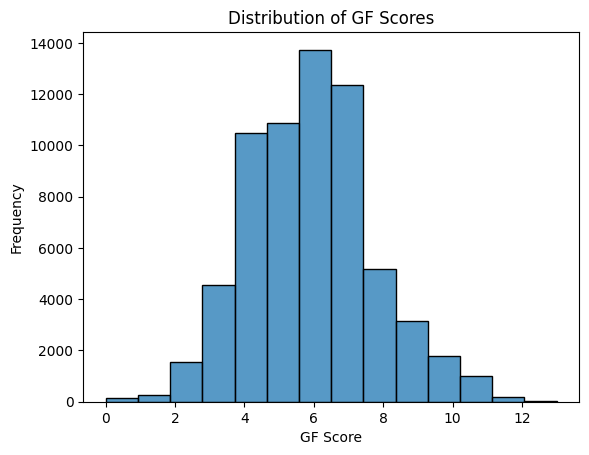

In [5]:
# Load the dataset
df = pd.read_csv('/opt/notebooks/combined_data_no_outliers/combined_data_GF_no_outliers.csv', index_col=0)
target_name = 'GF'

# Histogram of Fluid Intelligence Scores
sns.histplot(df['p20016_i2'], bins=14)
plt.title(f'Distribution of {target_name} Scores')
plt.xlabel(f'{target_name} Score')
plt.ylabel('Frequency')
plt.show()

In [6]:
print(len(df))
print(df.shape)

65296
(65296, 4113)


## GF vs. MIND

In [7]:
data_name = 'MIND'

# Set X and y
with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
    brain_regions = [line.strip() for line in f.readlines()]

# Define demographic/clinical features
demographic_vars = ['p31', 'p21003_i2', 'p54_i2']

# Combine demographic features with brain region features
all_vars = demographic_vars + brain_regions

X = df[all_vars]
y = df['p20016_i2']

print(X.shape)
print(y.shape)

(65296, 2281)
(65296,)


In [8]:
# rename columns
X = X.rename(columns=rename_dict)

categorical_vars = ['sex', 'assessment_centre']
continuous_vars  = [c for c in X.columns if c not in categorical_vars]

Fold 01 • n_comp=08 • MAE=1.520 • RMSE=1.911 • R²=0.051
Fold 02 • n_comp=08 • MAE=1.527 • RMSE=1.922 • R²=0.049
Fold 03 • n_comp=09 • MAE=1.491 • RMSE=1.886 • R²=0.061
Fold 04 • n_comp=09 • MAE=1.510 • RMSE=1.913 • R²=0.048
Fold 05 • n_comp=08 • MAE=1.515 • RMSE=1.909 • R²=0.058
Fold 06 • n_comp=09 • MAE=1.518 • RMSE=1.918 • R²=0.045
Fold 07 • n_comp=08 • MAE=1.506 • RMSE=1.896 • R²=0.056
Fold 08 • n_comp=09 • MAE=1.503 • RMSE=1.904 • R²=0.054
Fold 09 • n_comp=09 • MAE=1.536 • RMSE=1.932 • R²=0.055
Fold 10 • n_comp=08 • MAE=1.536 • RMSE=1.923 • R²=0.048

=== 10-fold CV summary ===
n_components (mean ± std): 8.5 ± 0.5
MAE :  1.516 ± 0.014
RMSE:  1.911 ± 0.013
R²  :  0.052 ± 0.005
PLS weights saved to: /opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_GF.csv
Final model parameters: n_components=8
PLS1: Top edge weight magnitude: 0.0559


/tmp/ipykernel_103/1078655613.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar


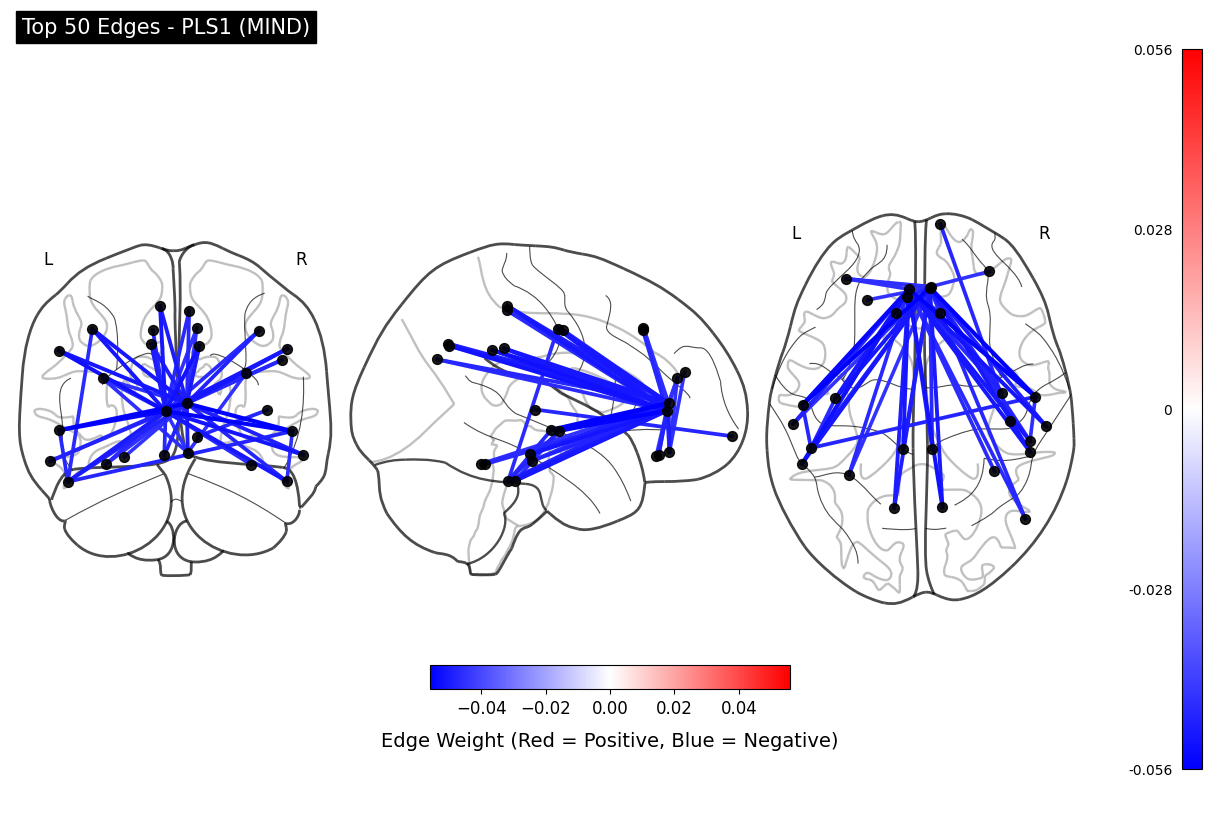

PLS2: Top edge weight magnitude: 0.0687


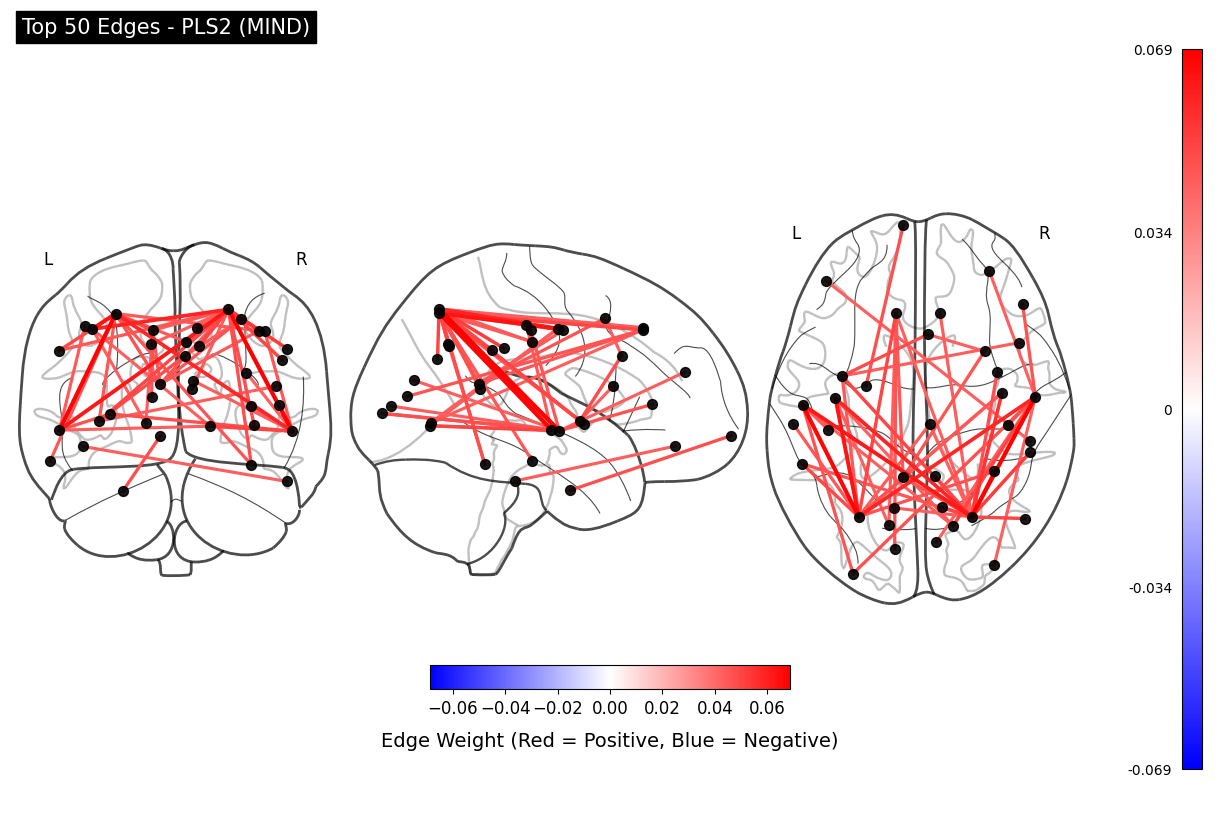

PLS3: Top edge weight magnitude: 0.0723


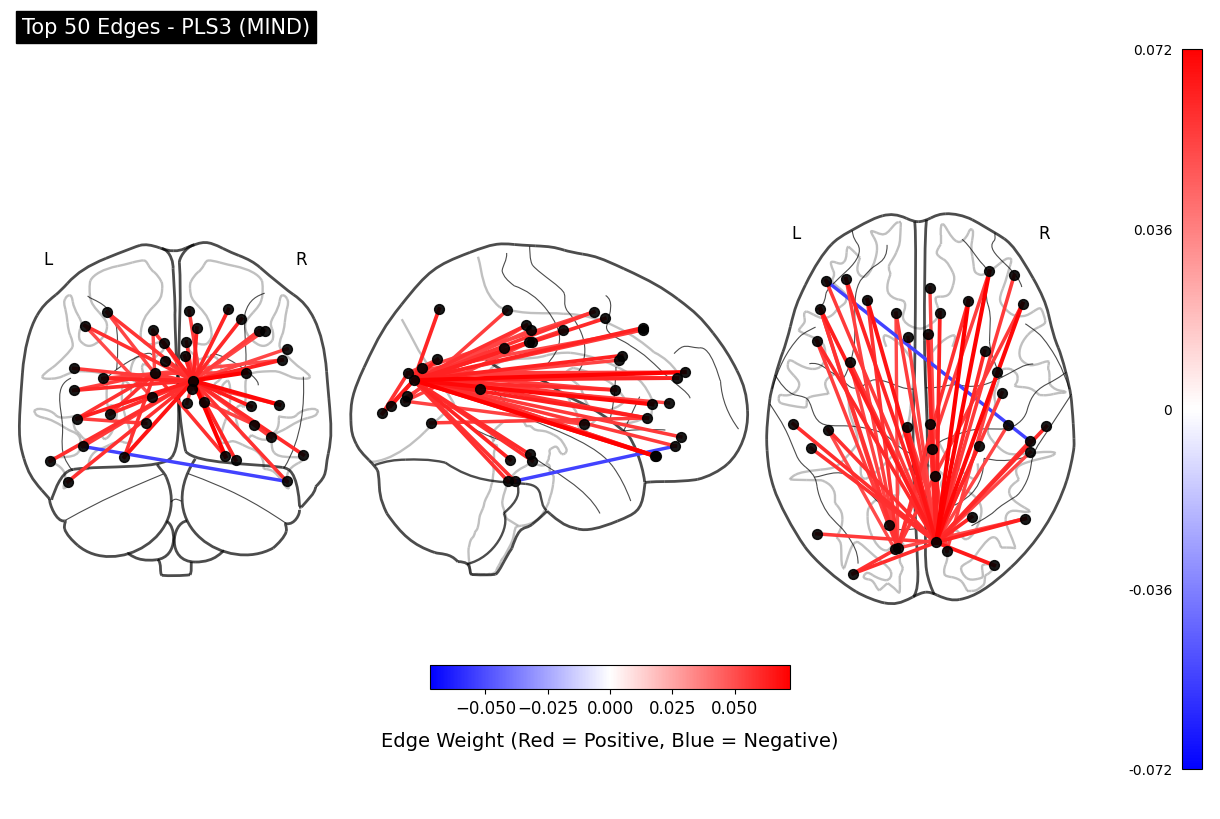

In [9]:
pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10)

# PAL

/opt/conda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


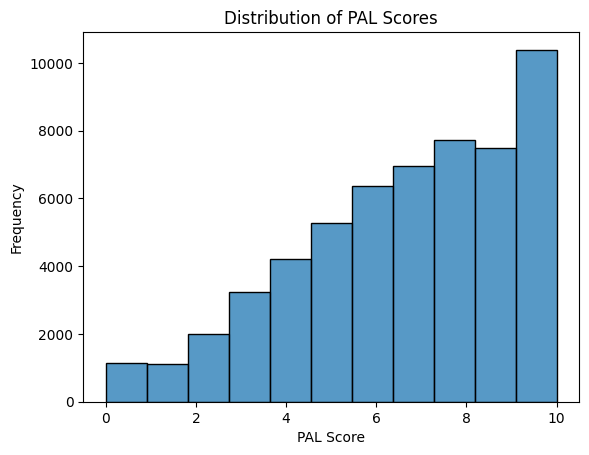

In [30]:
# Load the dataset
df = pd.read_csv('/opt/notebooks/combined_data_no_outliers/combined_data_PAL_no_outliers.csv', index_col=0)
target_name = 'PAL'

# Histogram of PAL Scores
sns.histplot(df['p20197_i2'], bins=11)
plt.title(f'Distribution of {target_name} Scores')
plt.xlabel(f'{target_name} Score')
plt.ylabel('Frequency')
plt.show()

In [31]:
print(len(df))
print(df.shape)

55900
(55900, 4113)


### PAL vs. MIND

In [32]:
data_name = 'MIND'

# Set X and y
with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
    brain_regions = [line.strip() for line in f.readlines()]

# Define demographic/clinical features
demographic_vars = ['p31', 'p21003_i2', 'p54_i2']
# Combine demographic features with brain region features
all_vars = demographic_vars + brain_regions

X = df[all_vars]
y = df['p20197_i2']

print(X.shape)
print(y.shape)

(55900, 2281)
(55900,)


In [33]:
# rename columns
X = X.rename(columns=rename_dict)

categorical_vars = ['sex', 'assessment_centre']
continuous_vars  = [c for c in X.columns if c not in categorical_vars]

Fold 01 • n_comp=10 • MAE=2.140 • RMSE=2.591 • R²=0.061
Fold 02 • n_comp=10 • MAE=2.083 • RMSE=2.536 • R²=0.072
Fold 03 • n_comp=10 • MAE=2.077 • RMSE=2.522 • R²=0.062
Fold 04 • n_comp=10 • MAE=2.091 • RMSE=2.549 • R²=0.056
Fold 05 • n_comp=10 • MAE=2.141 • RMSE=2.595 • R²=0.066
Fold 06 • n_comp=10 • MAE=2.106 • RMSE=2.565 • R²=0.065
Fold 07 • n_comp=10 • MAE=2.110 • RMSE=2.565 • R²=0.053
Fold 08 • n_comp=10 • MAE=2.106 • RMSE=2.567 • R²=0.062
Fold 09 • n_comp=10 • MAE=2.114 • RMSE=2.559 • R²=0.067
Fold 10 • n_comp=10 • MAE=2.132 • RMSE=2.579 • R²=0.062

=== 10-fold CV summary ===
n_components (mean ± std): 10.0 ± 0.0
MAE :  2.110 ± 0.021
RMSE:  2.563 ± 0.022
R²  :  0.063 ± 0.005
PLS weights saved to: /opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_PAL.csv
Final model parameters: n_components=10
PLS1: Top edge weight magnitude: 0.0726


/tmp/ipykernel_103/1078655613.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar


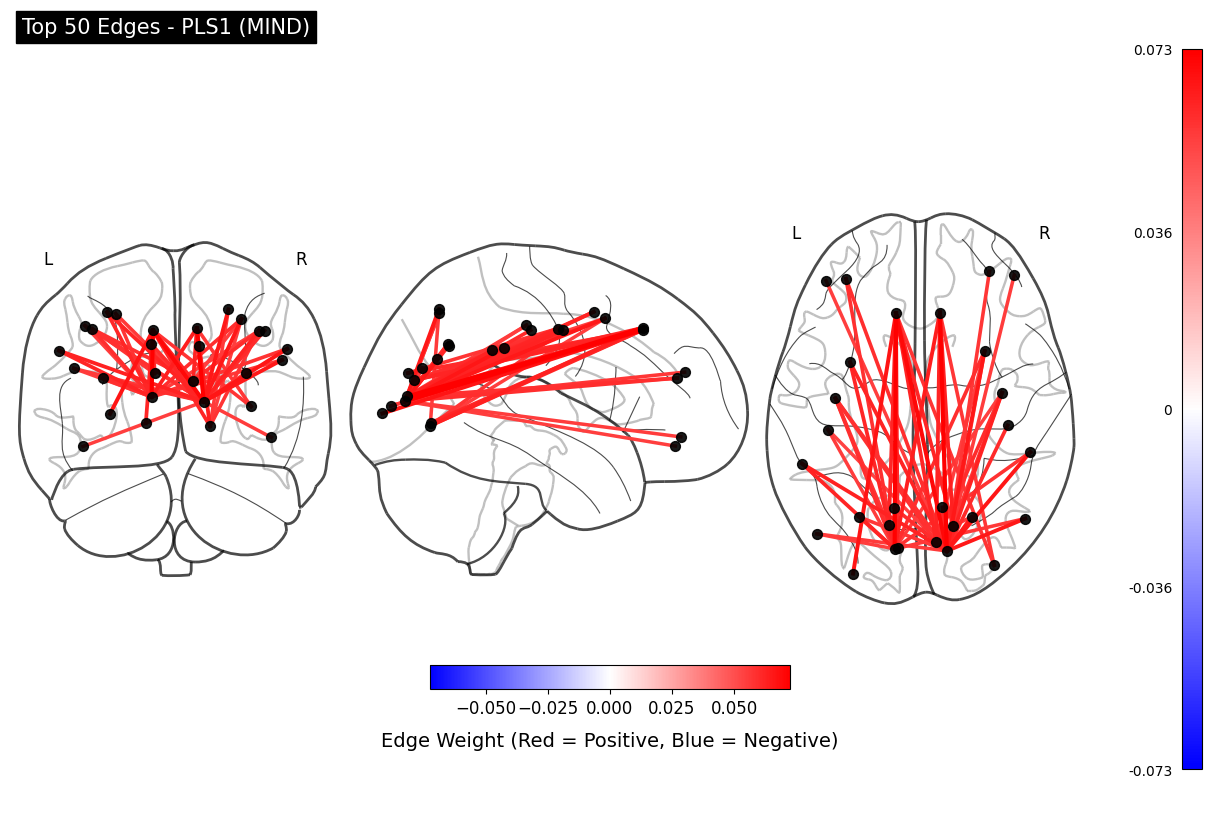

PLS2: Top edge weight magnitude: 0.0636


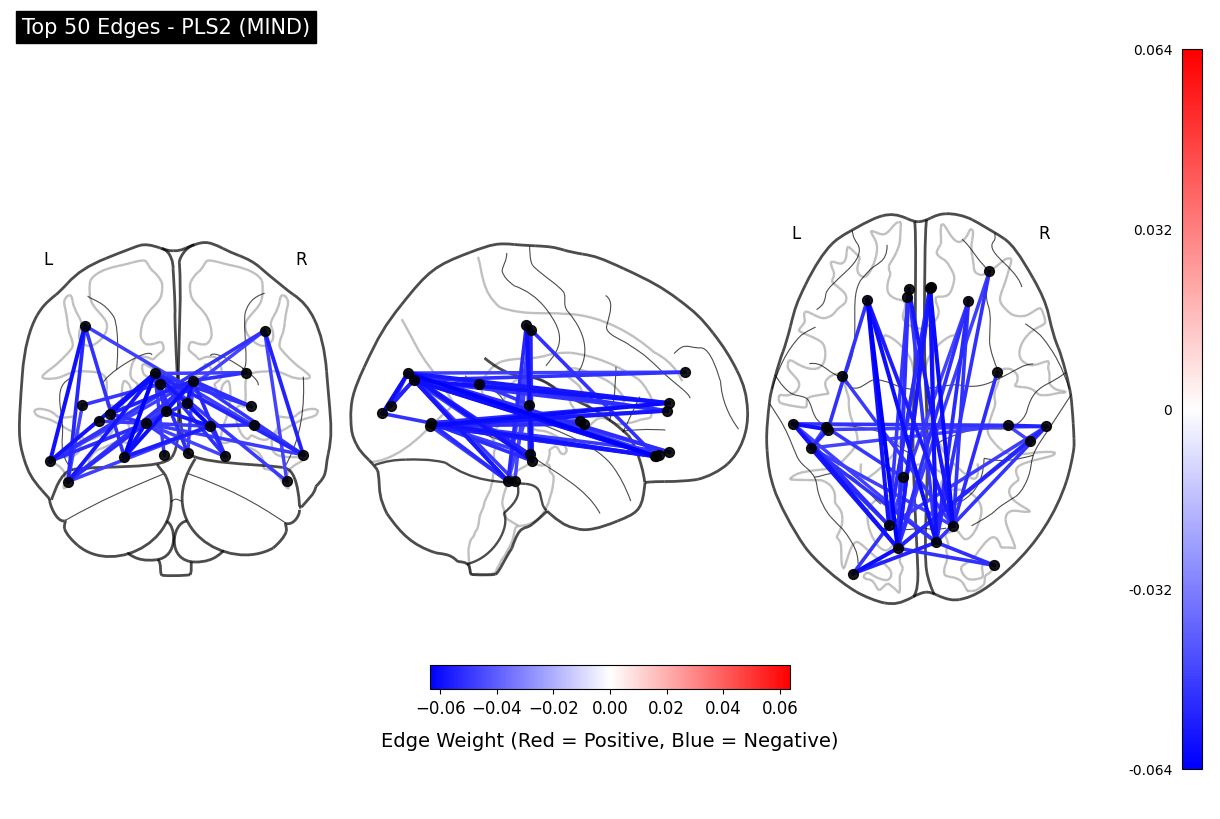

PLS3: Top edge weight magnitude: 0.0530


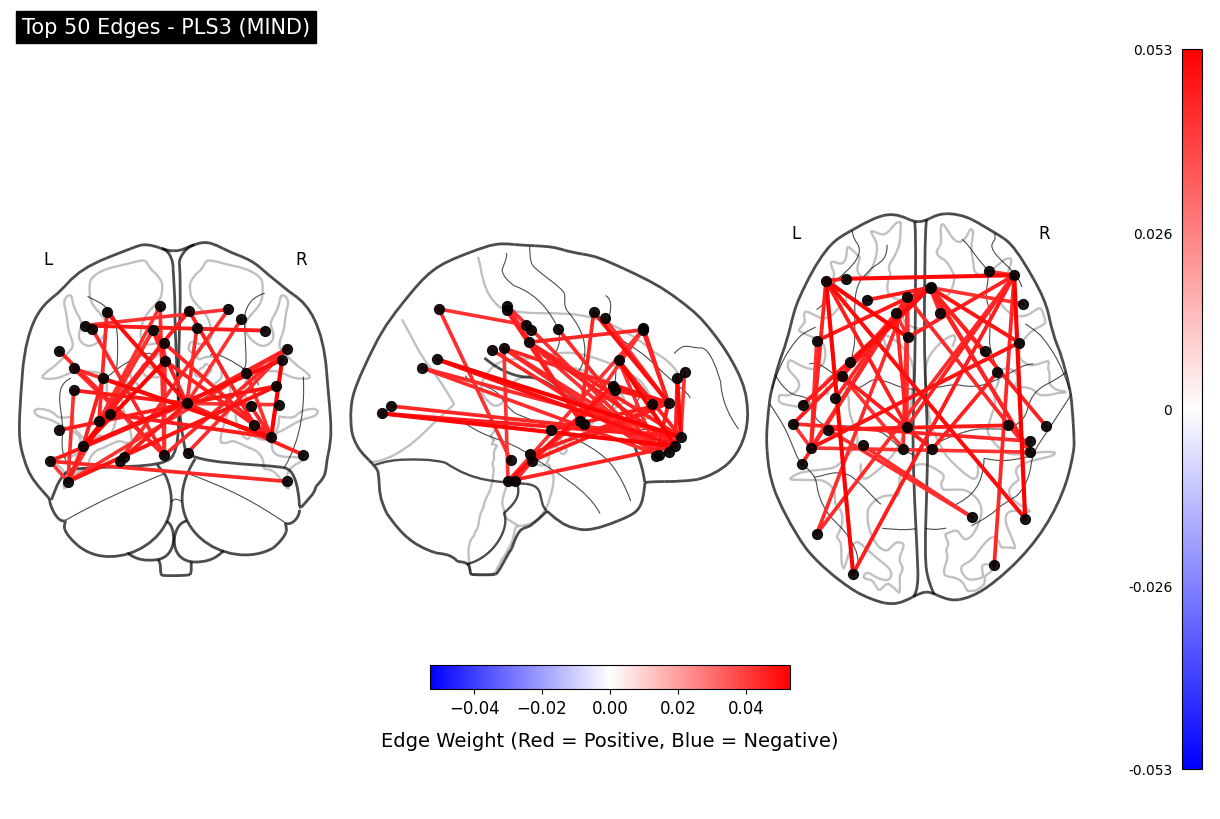

In [34]:
pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10)

# DSST

/opt/conda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


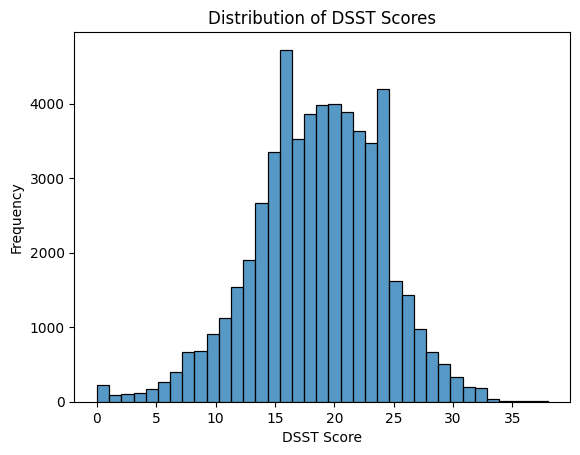

In [35]:
# Load the dataset
df = pd.read_csv('/opt/notebooks/combined_data_no_outliers/combined_data_DSST_no_outliers.csv', index_col=0)
target_name = 'DSST'

# Histogram of DSST Scores
sns.histplot(df['p23324_i2'], bins=37)
plt.title(f'Distribution of {target_name} Scores')
plt.xlabel(f'{target_name} Score')
plt.ylabel('Frequency')
plt.show()

In [36]:
print(len(df))
print(df.shape)

55460
(55460, 4113)


### DSST vs. MIND

In [37]:
data_name = 'MIND'

# Set X and y
with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
    brain_regions = [line.strip() for line in f.readlines()]

# Define demographic/clinical features
demographic_vars = ['p31', 'p21003_i2', 'p54_i2']

# Combine demographic features with brain region features
all_vars = demographic_vars + brain_regions

X = df[all_vars]
y = df['p23324_i2']

print(X.shape)
print(y.shape)

(55460, 2281)
(55460,)


In [38]:
# rename columns
X = X.rename(columns=rename_dict)

categorical_vars = ['sex', 'assessment_centre']
continuous_vars  = [c for c in X.columns if c not in categorical_vars]

Fold 01 • n_comp=10 • MAE=3.742 • RMSE=4.777 • R²=0.182
Fold 02 • n_comp=10 • MAE=3.695 • RMSE=4.694 • R²=0.207
Fold 03 • n_comp=10 • MAE=3.738 • RMSE=4.740 • R²=0.189
Fold 04 • n_comp=10 • MAE=3.646 • RMSE=4.680 • R²=0.197
Fold 05 • n_comp=10 • MAE=3.698 • RMSE=4.714 • R²=0.184
Fold 06 • n_comp=10 • MAE=3.695 • RMSE=4.708 • R²=0.204
Fold 07 • n_comp=10 • MAE=3.701 • RMSE=4.732 • R²=0.177
Fold 08 • n_comp=10 • MAE=3.750 • RMSE=4.747 • R²=0.198
Fold 09 • n_comp=10 • MAE=3.703 • RMSE=4.718 • R²=0.192
Fold 10 • n_comp=10 • MAE=3.701 • RMSE=4.687 • R²=0.183

=== 10-fold CV summary ===
n_components (mean ± std): 10.0 ± 0.0
MAE :  3.707 ± 0.029
RMSE:  4.720 ± 0.028
R²  :  0.191 ± 0.010
PLS weights saved to: /opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_DSST.csv
Final model parameters: n_components=10
PLS1: Top edge weight magnitude: 0.0675


/tmp/ipykernel_103/1078655613.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar


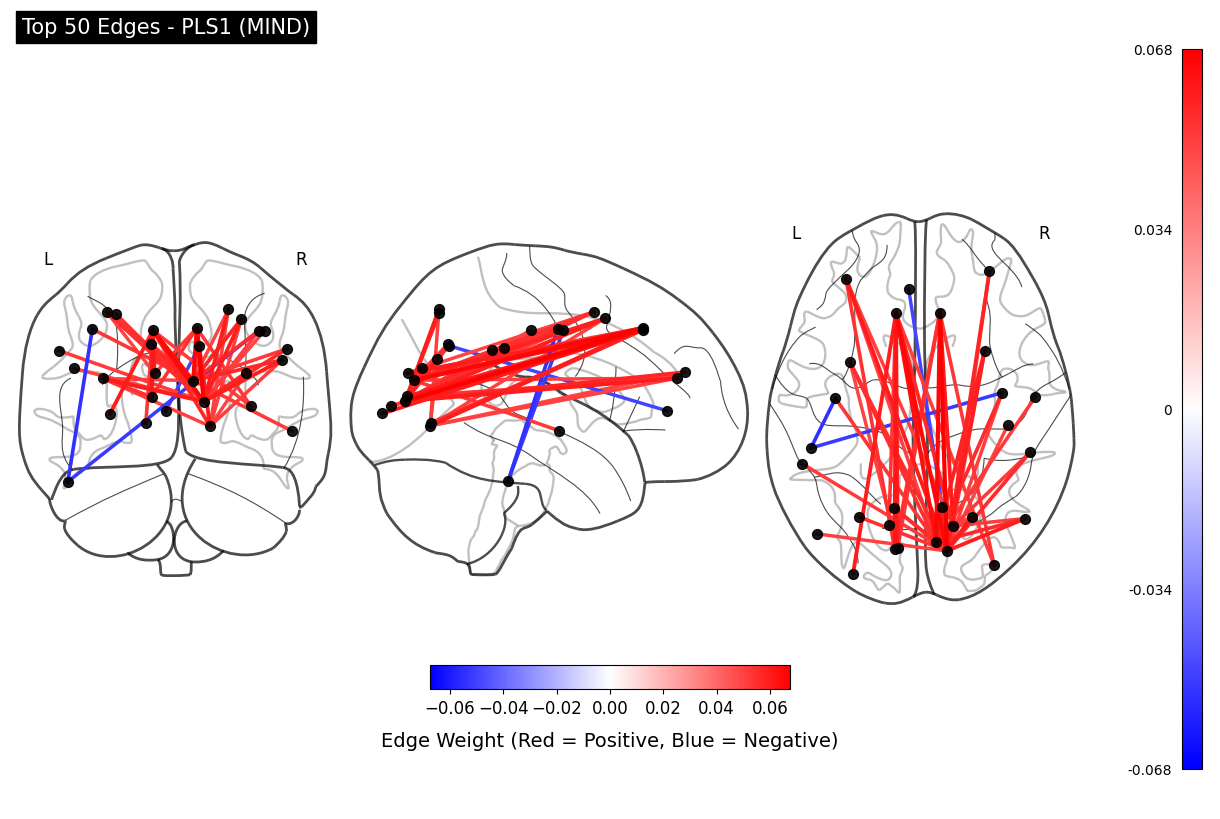

PLS2: Top edge weight magnitude: 0.0592


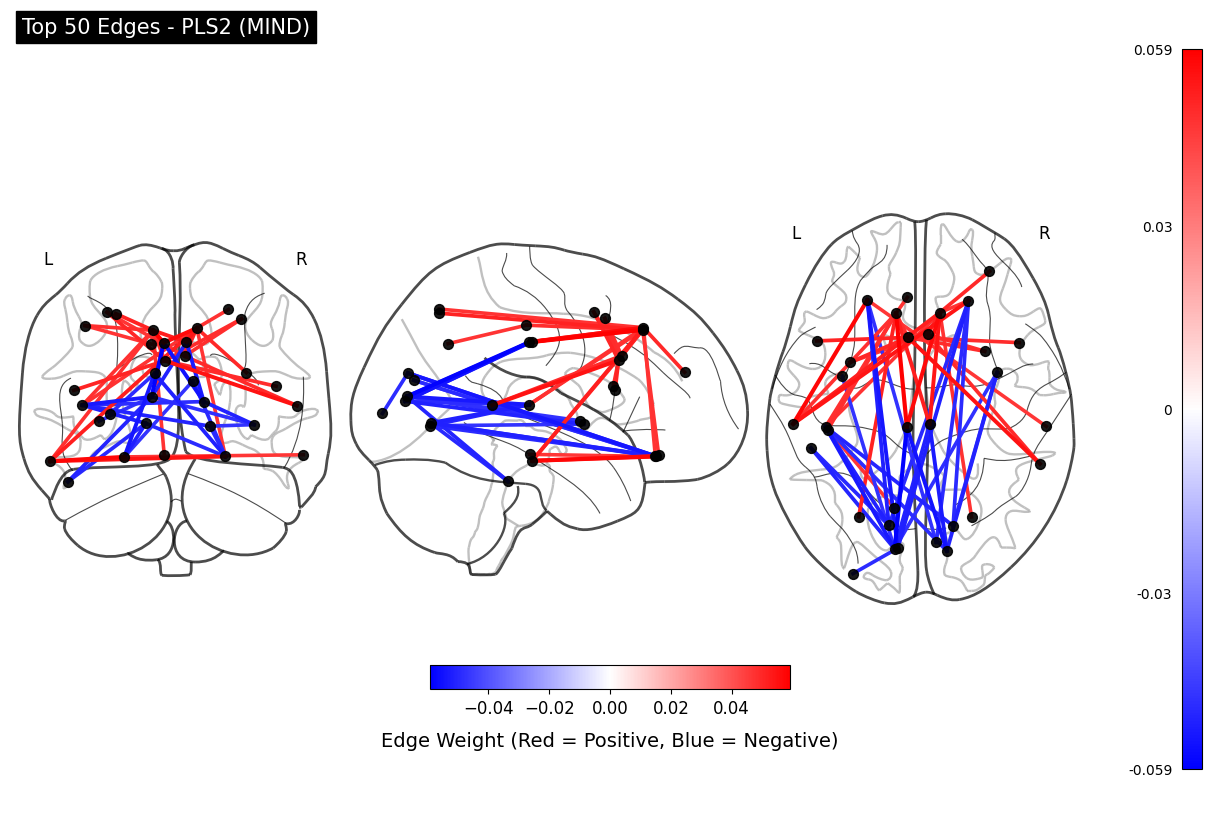

PLS3: Top edge weight magnitude: 0.0646


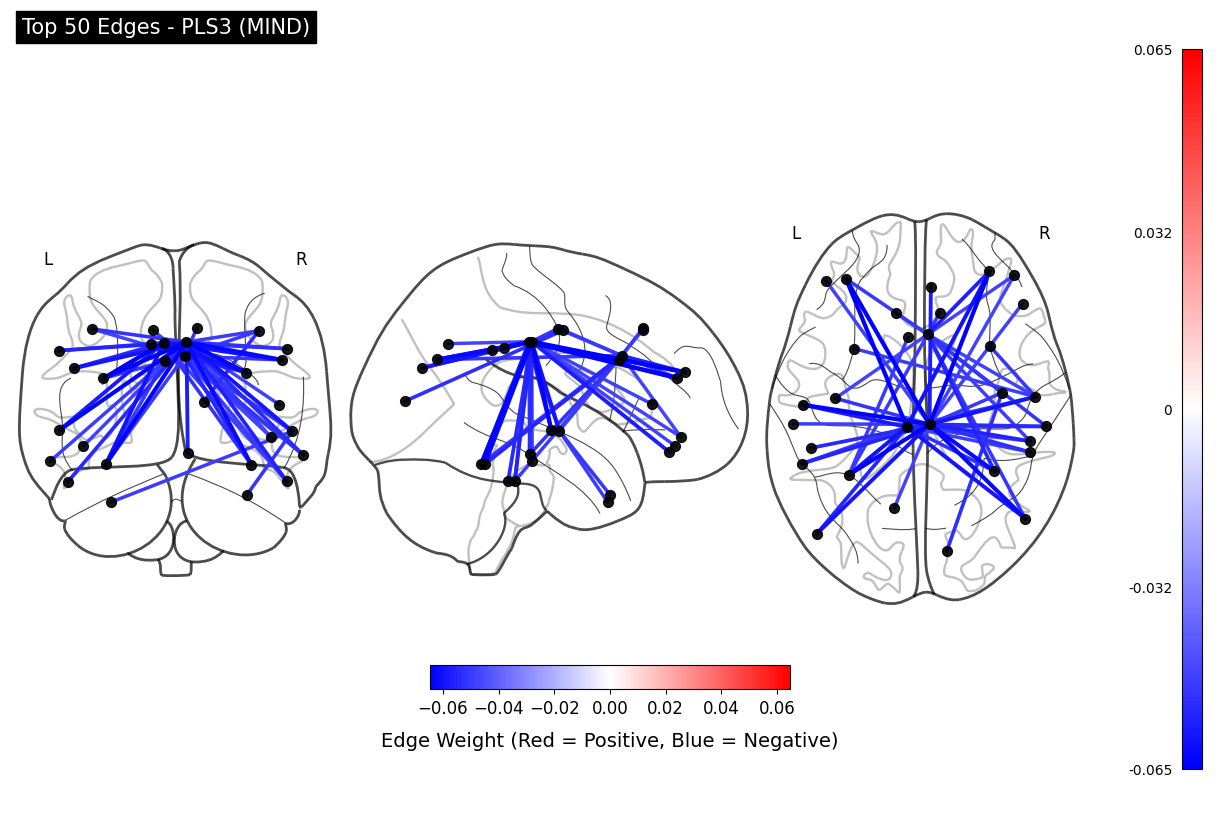

In [39]:
pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10)

Fold 01 • n_comp=10 • MAE=3.742 • RMSE=4.777 • R²=0.182
Fold 02 • n_comp=10 • MAE=3.695 • RMSE=4.694 • R²=0.207
Fold 03 • n_comp=10 • MAE=3.738 • RMSE=4.740 • R²=0.189
Fold 04 • n_comp=10 • MAE=3.646 • RMSE=4.680 • R²=0.197
Fold 05 • n_comp=10 • MAE=3.698 • RMSE=4.714 • R²=0.184
Fold 06 • n_comp=10 • MAE=3.695 • RMSE=4.708 • R²=0.204
Fold 07 • n_comp=10 • MAE=3.701 • RMSE=4.732 • R²=0.177
Fold 08 • n_comp=10 • MAE=3.750 • RMSE=4.747 • R²=0.198
Fold 09 • n_comp=10 • MAE=3.703 • RMSE=4.718 • R²=0.192
Fold 10 • n_comp=10 • MAE=3.701 • RMSE=4.687 • R²=0.183

=== 10-fold CV summary ===
n_components (mean ± std): 10.0 ± 0.0
MAE :  3.707 ± 0.029
RMSE:  4.720 ± 0.028
R²  :  0.191 ± 0.010
PLS weights saved to: /opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_DSST.csv
Final model parameters: n_components=10
PLS1: Top edge weight magnitude: 0.0675


/tmp/ipykernel_103/1078655613.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar


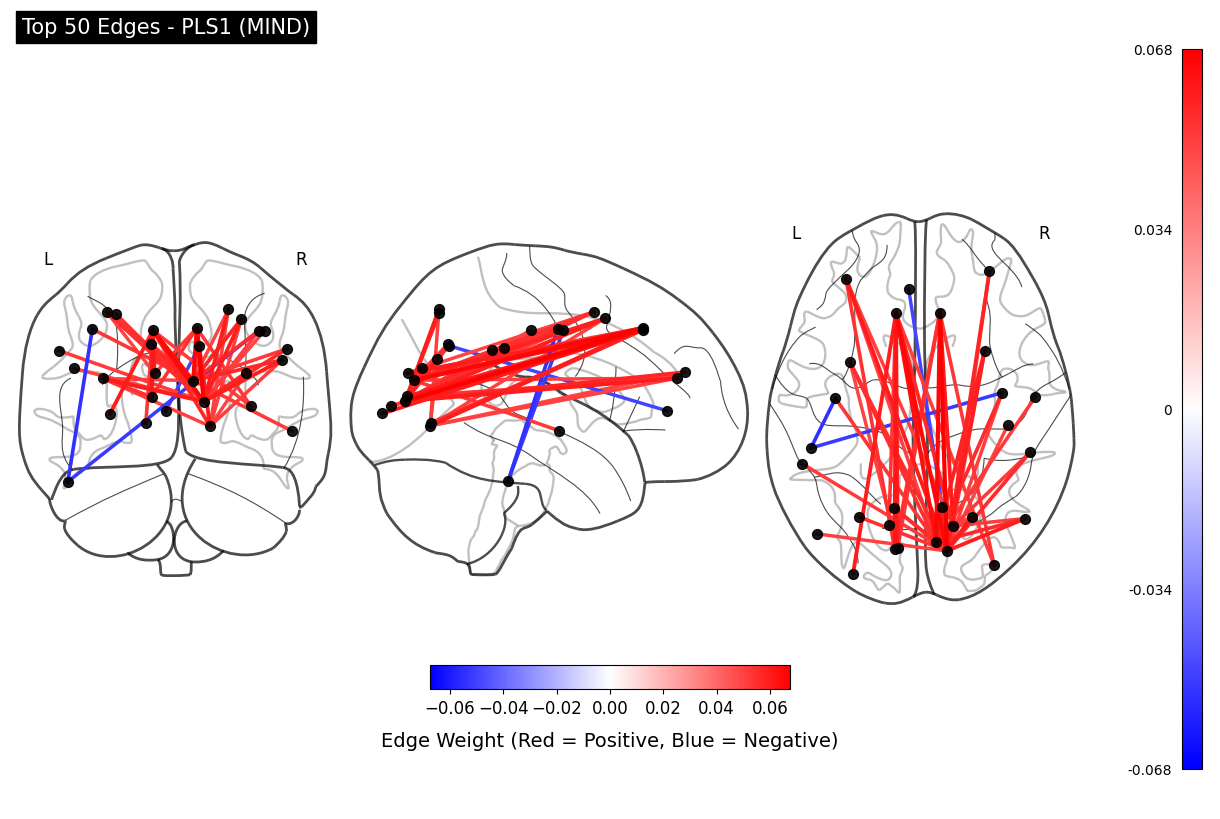

PLS2: Top edge weight magnitude: 0.0592


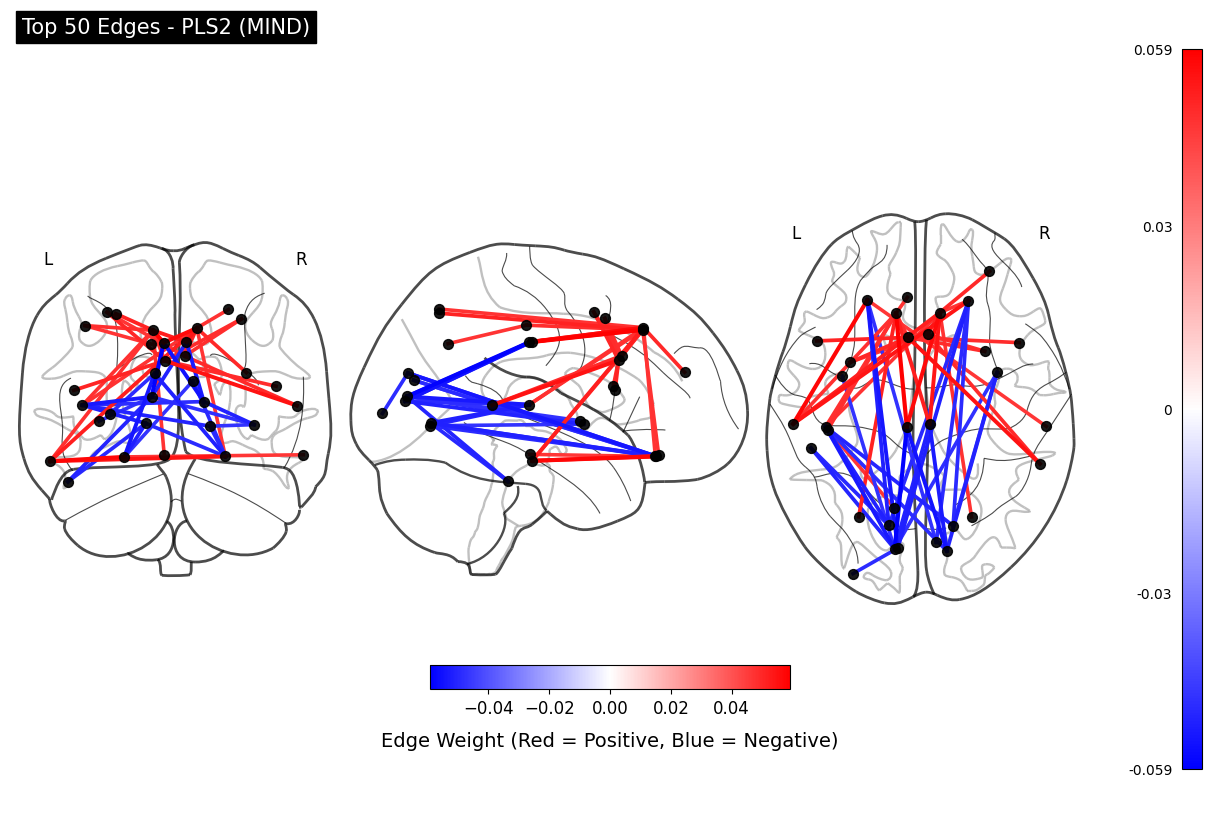

PLS3: Top edge weight magnitude: 0.0646


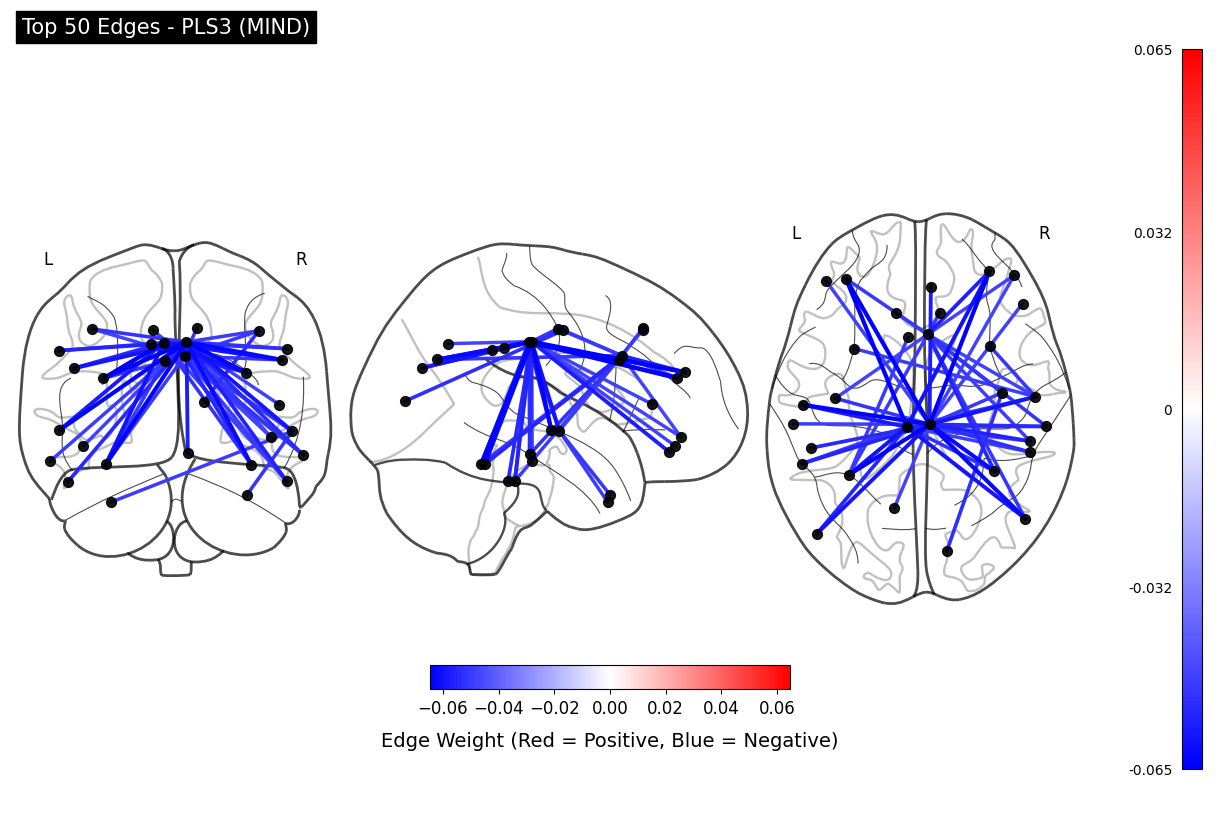

In [40]:
pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10)

# TMT

/opt/conda/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


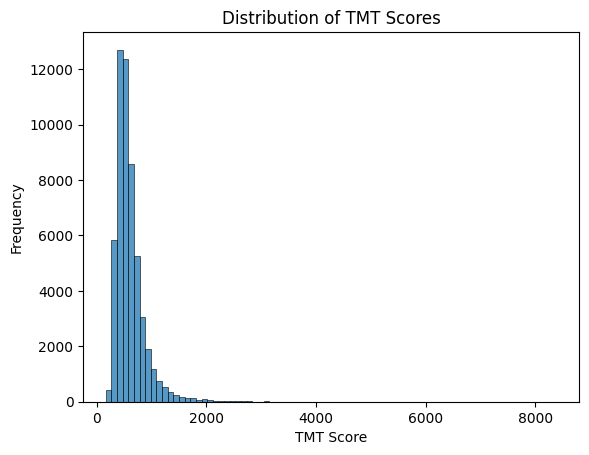

In [41]:
# Load the dataset
df = pd.read_csv('/opt/notebooks/combined_data_no_outliers/combined_data_TMT_no_outliers.csv', index_col=0)
target_name = 'TMT'

# Histogram of TMT Scores
sns.histplot(df['trailmaking_score'], bins=80)
plt.title(f'Distribution of {target_name} Scores')
plt.xlabel(f'{target_name} Score')
plt.ylabel('Frequency')
plt.show()

In [42]:
print(len(df))
print(df.shape)

54102
(54102, 4113)


### TMT vs. MIND

In [43]:
data_name = 'MIND'

# Set X and y
with open('/opt/notebooks/MIND_models/region_names/MIND_regions.txt', 'r') as f:
    brain_regions = [line.strip() for line in f.readlines()]

# Define demographic/clinical features
demographic_vars = ['p31', 'p21003_i2', 'p54_i2']

# Combine demographic features with brain region features
all_vars = demographic_vars + brain_regions

X = df[all_vars]
y = df['trailmaking_score']

print(X.shape)
print(y.shape)

(54102, 2281)
(54102,)


In [44]:
# rename columns
X = X.rename(columns=rename_dict)

categorical_vars = ['sex', 'assessment_centre']
continuous_vars  = [c for c in X.columns if c not in categorical_vars]

Fold 01 • n_comp=10 • MAE=174.213 • RMSE=263.915 • R²=0.119
Fold 02 • n_comp=10 • MAE=174.578 • RMSE=274.589 • R²=0.116
Fold 03 • n_comp=10 • MAE=173.716 • RMSE=279.555 • R²=0.113
Fold 04 • n_comp=10 • MAE=178.611 • RMSE=282.192 • R²=0.118
Fold 05 • n_comp=10 • MAE=172.597 • RMSE=265.142 • R²=0.127
Fold 06 • n_comp=10 • MAE=175.000 • RMSE=269.410 • R²=0.127
Fold 07 • n_comp=10 • MAE=173.212 • RMSE=266.070 • R²=0.131
Fold 08 • n_comp=10 • MAE=169.550 • RMSE=261.021 • R²=0.122
Fold 09 • n_comp=10 • MAE=176.279 • RMSE=274.460 • R²=0.112
Fold 10 • n_comp=10 • MAE=178.854 • RMSE=276.918 • R²=0.122

=== 10-fold CV summary ===
n_components (mean ± std): 10.0 ± 0.0
MAE :  174.661 ± 2.636
RMSE:  271.327 ± 6.842
R²  :  0.121 ± 0.006
PLS weights saved to: /opt/notebooks/MIND_models/models_plsregression_dnanexus/PLS_weights/PLS_weights_MIND_TMT.csv
Final model parameters: n_components=10
PLS1: Top edge weight magnitude: 0.0596


/tmp/ipykernel_103/1078655613.py:252: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 1, 1])  # Make room for colorbar


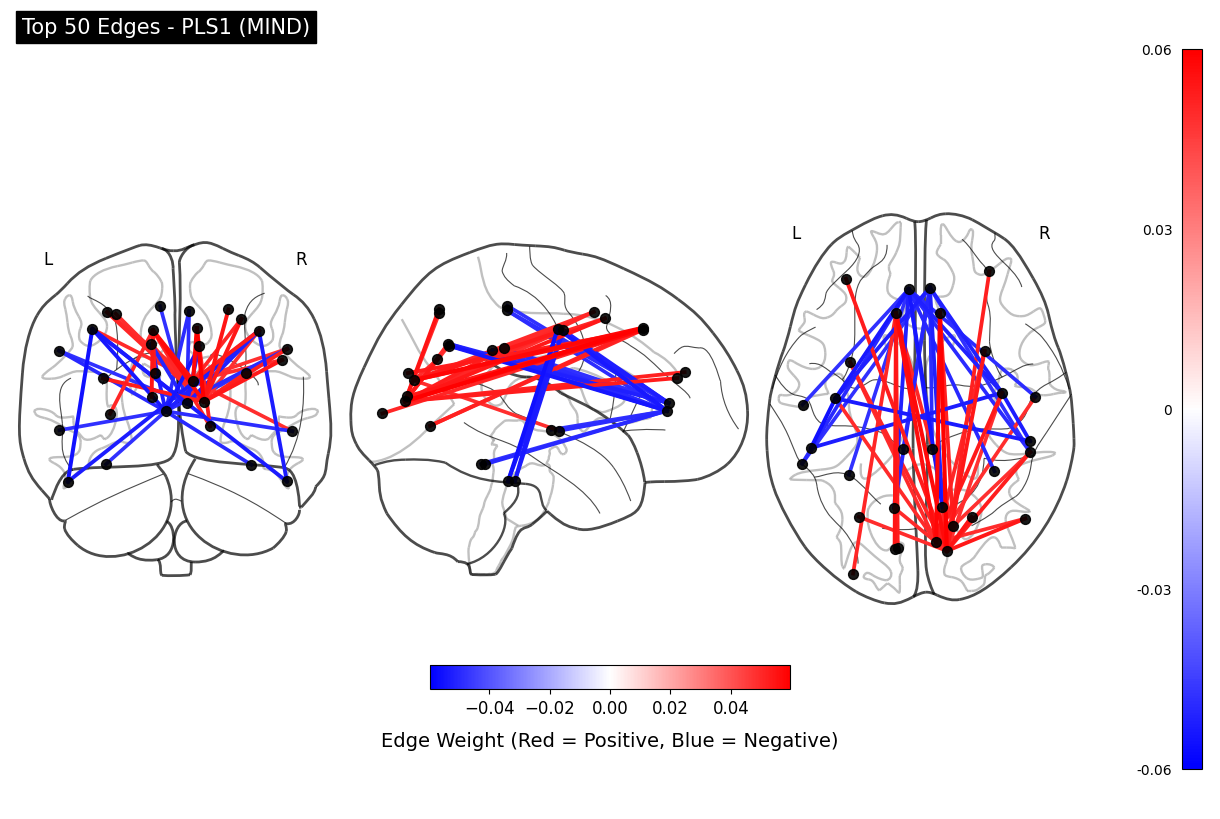

PLS2: Top edge weight magnitude: 0.0587


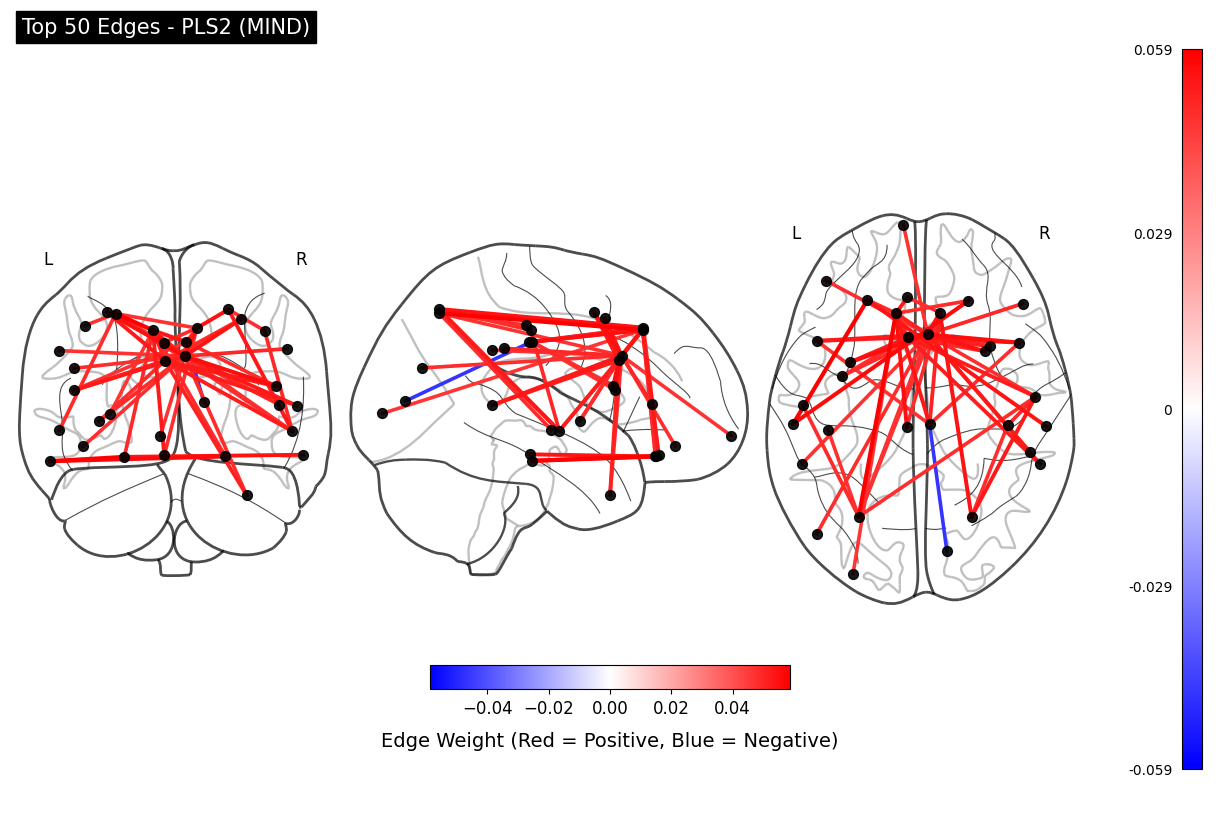

PLS3: Top edge weight magnitude: 0.0592


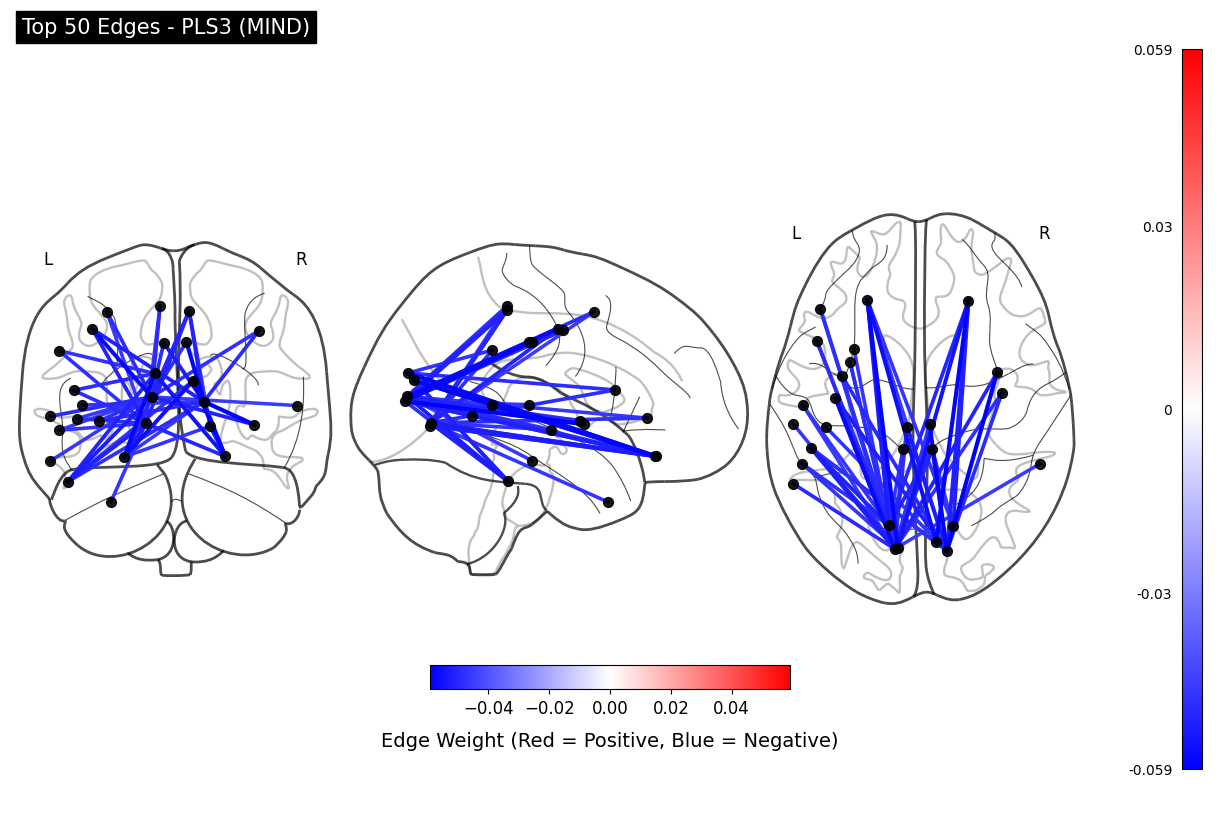

In [45]:
pls_analysis(X, y, continuous_vars, categorical_vars, weights_dir, data_name, target_name, n_splits=10)